In [1]:
import numpy as np
from core import Simulation
import matplotlib.pyplot as plt
import pandas as pd
import eurostat
from data_scraper import *
from plotter import *
import geopandas as gpd
import imageio
import os
from scipy import stats


In [2]:
# Intrested in the year
Y = 2022
filename="connectivity_"+str(Y)+".csv"

# Fetch transportation data
df_connectivity = fetch_eu_air_traffic(year=Y, filename=filename, check=filename)

# Fetch population data
df_pop = fetch_eu_populations(year=Y)
df_pop = df_pop.set_index("Country_Code")

+ Fetching Eurostat Air Traffic Data...
Loaded succesfully!
+ Fetching Eurostat Population Data...
   -> Successfully loaded populations for 50 entities.


In [3]:
# Filter out cities with air traffic and Nan pop values
df_pop = df_pop.dropna()
valid_countries = df_pop.index.tolist()
valid_nodes = [node for node in df_connectivity.index if node in valid_countries]
df_connectivity = df_connectivity.loc[valid_nodes, valid_nodes]
df_pop = df_pop.loc[df_connectivity.index.to_list()]

In [4]:
population = df_pop.to_numpy().flatten()

# Seed 0.1% infection in a moderately populated country; rest fully susceptible

mode = np.median(population)

def find_nearest_idx(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

mode_idx = find_nearest_idx(population, mode)

S0 = population
S0[mode_idx] = 0.999 * mode

I0 = np.zeros_like(population)
I0[mode_idx] = 0.001 * mode

R0 = np.zeros_like(population)
init_state = np.concatenate([S0, I0, R0])

# Asymmetric commuter matrix; zero diagonal; rows sum to 0.1
C = df_connectivity.to_numpy()

infection_rate=0.2
recovery_rate=1_000_000
social_connectivity=0.5

sim = Simulation(
    populations=population,
    init_state=init_state,
    connection_matrix=C,
    infection_rate=infection_rate,       
    recovery_rate=recovery_rate,        
    social_connectivity=social_connectivity,
)
sim.solve_system(t_end=360) 
t, S, I, R = sim.get_results()

print("Location :", valid_countries[mode_idx], "; Population :", mode)

Location : AZ ; Population : 6639794.5


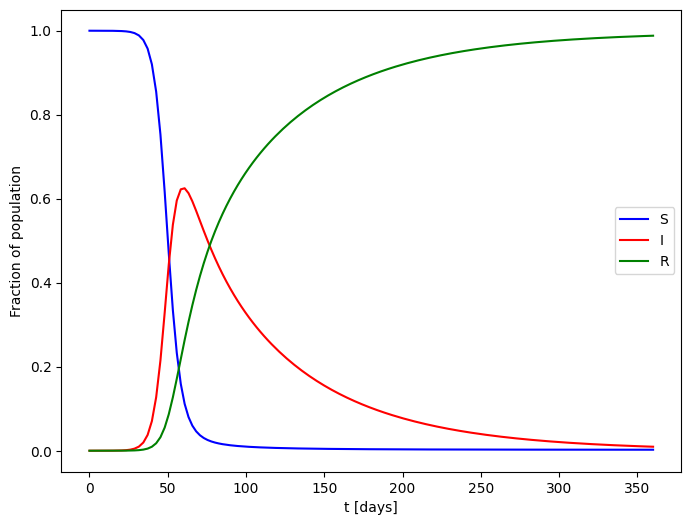

In [5]:
simple_plot(t, S, I, R).plot();

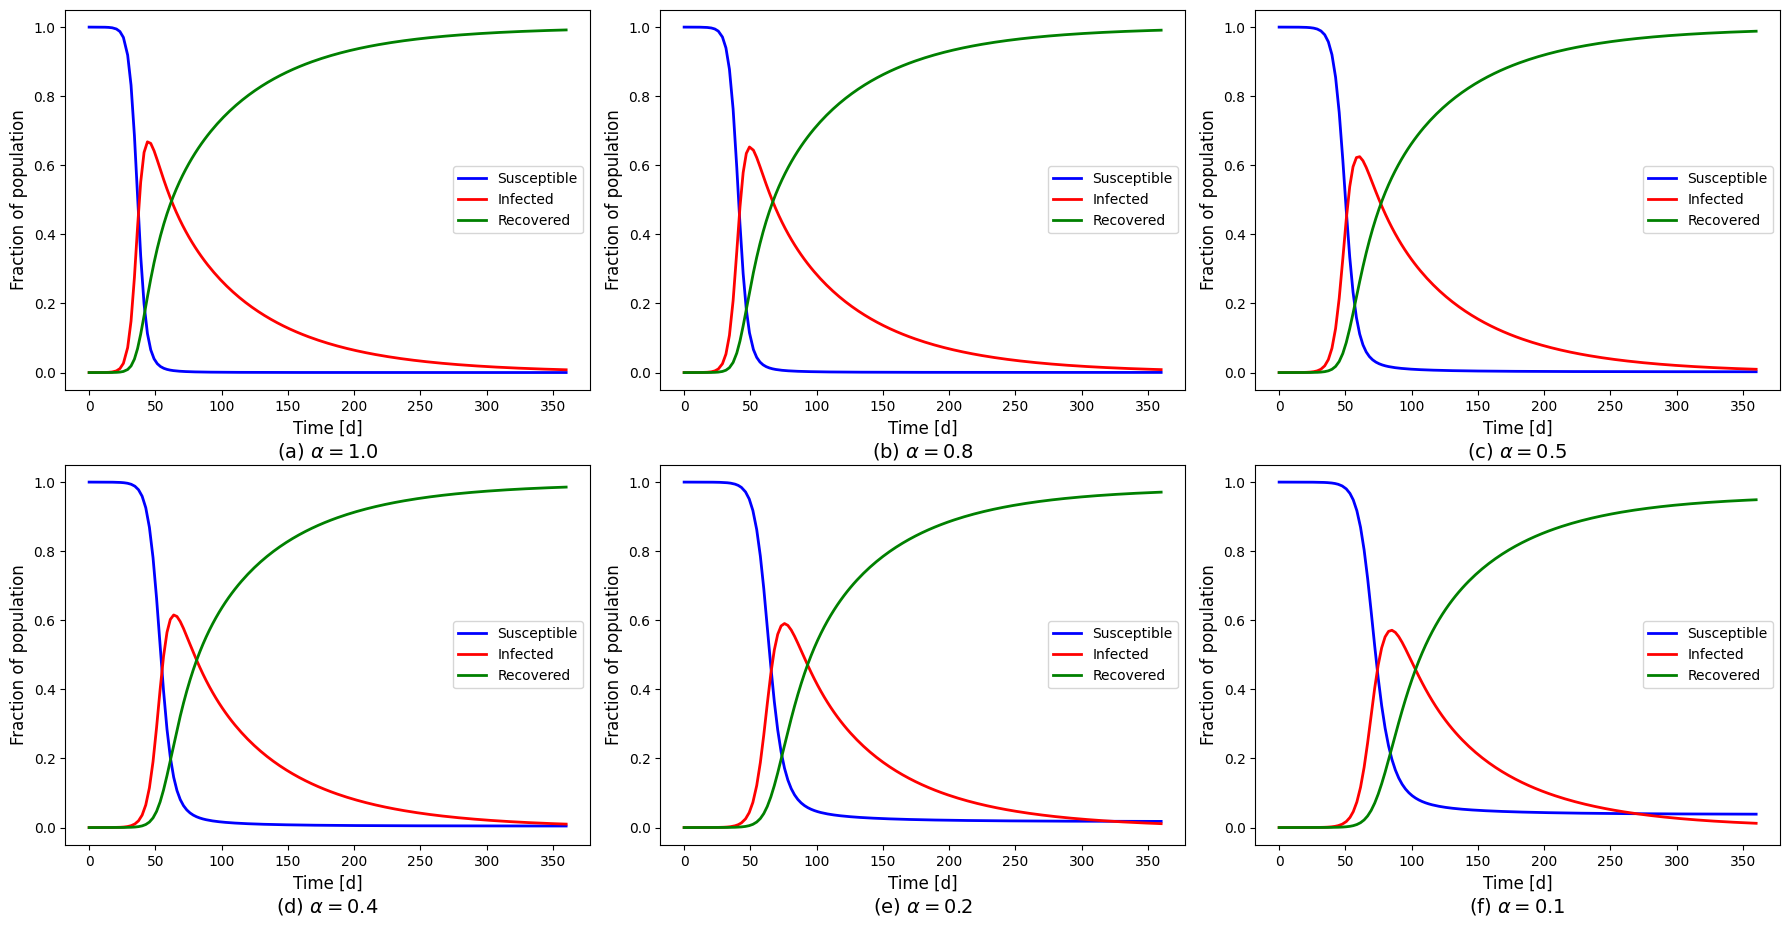

In [6]:
social_connectivity_comp(population, init_state, C,
                          t_end=360, infection_rate=infection_rate, recovery_rate=recovery_rate)

Location : HR ; Population : 375871.752


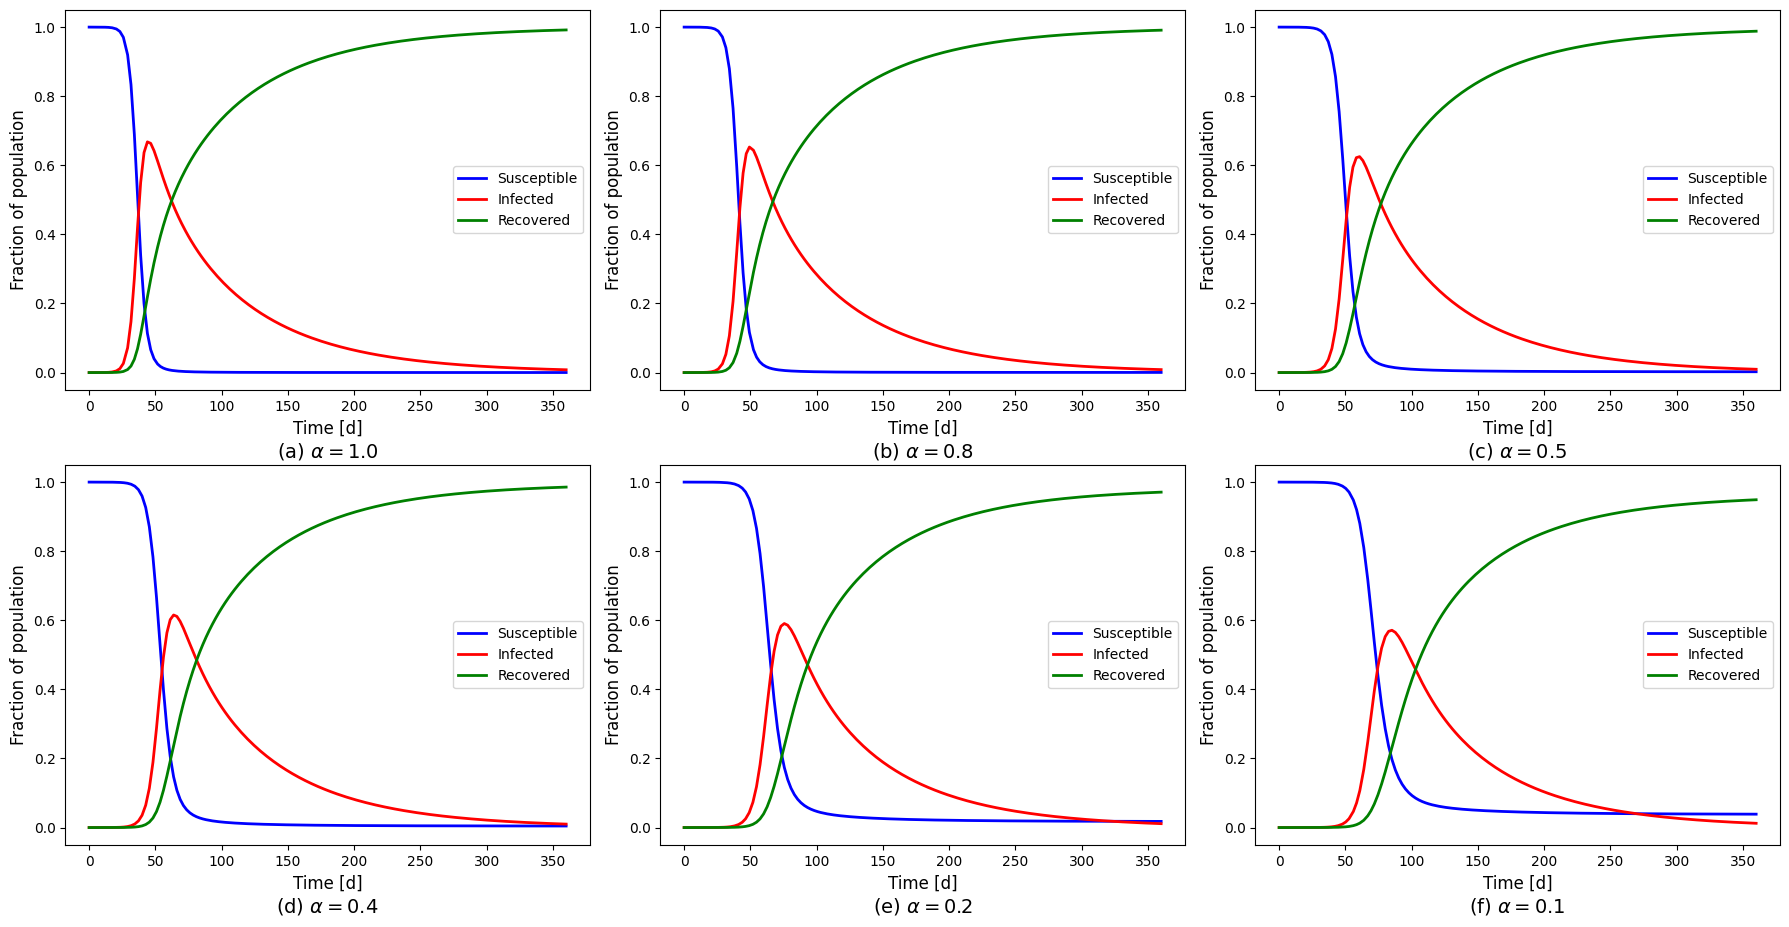

In [7]:
# Seed 0.1% infection in the lowest populated country; rest fully susceptible
S0 = population
S0[np.argmin(population)] = 0.999 * np.min(population)

I0 = np.zeros_like(population)
I0[np.argmin(population)] = 0.001 * np.min(population)

print("Location :", valid_countries[np.argmin(population)], "; Population :", np.min(population))

social_connectivity_comp(population, init_state, C,
                          t_end=360, infection_rate=infection_rate, recovery_rate=recovery_rate)

Location : RO ; Population : 84595592.727


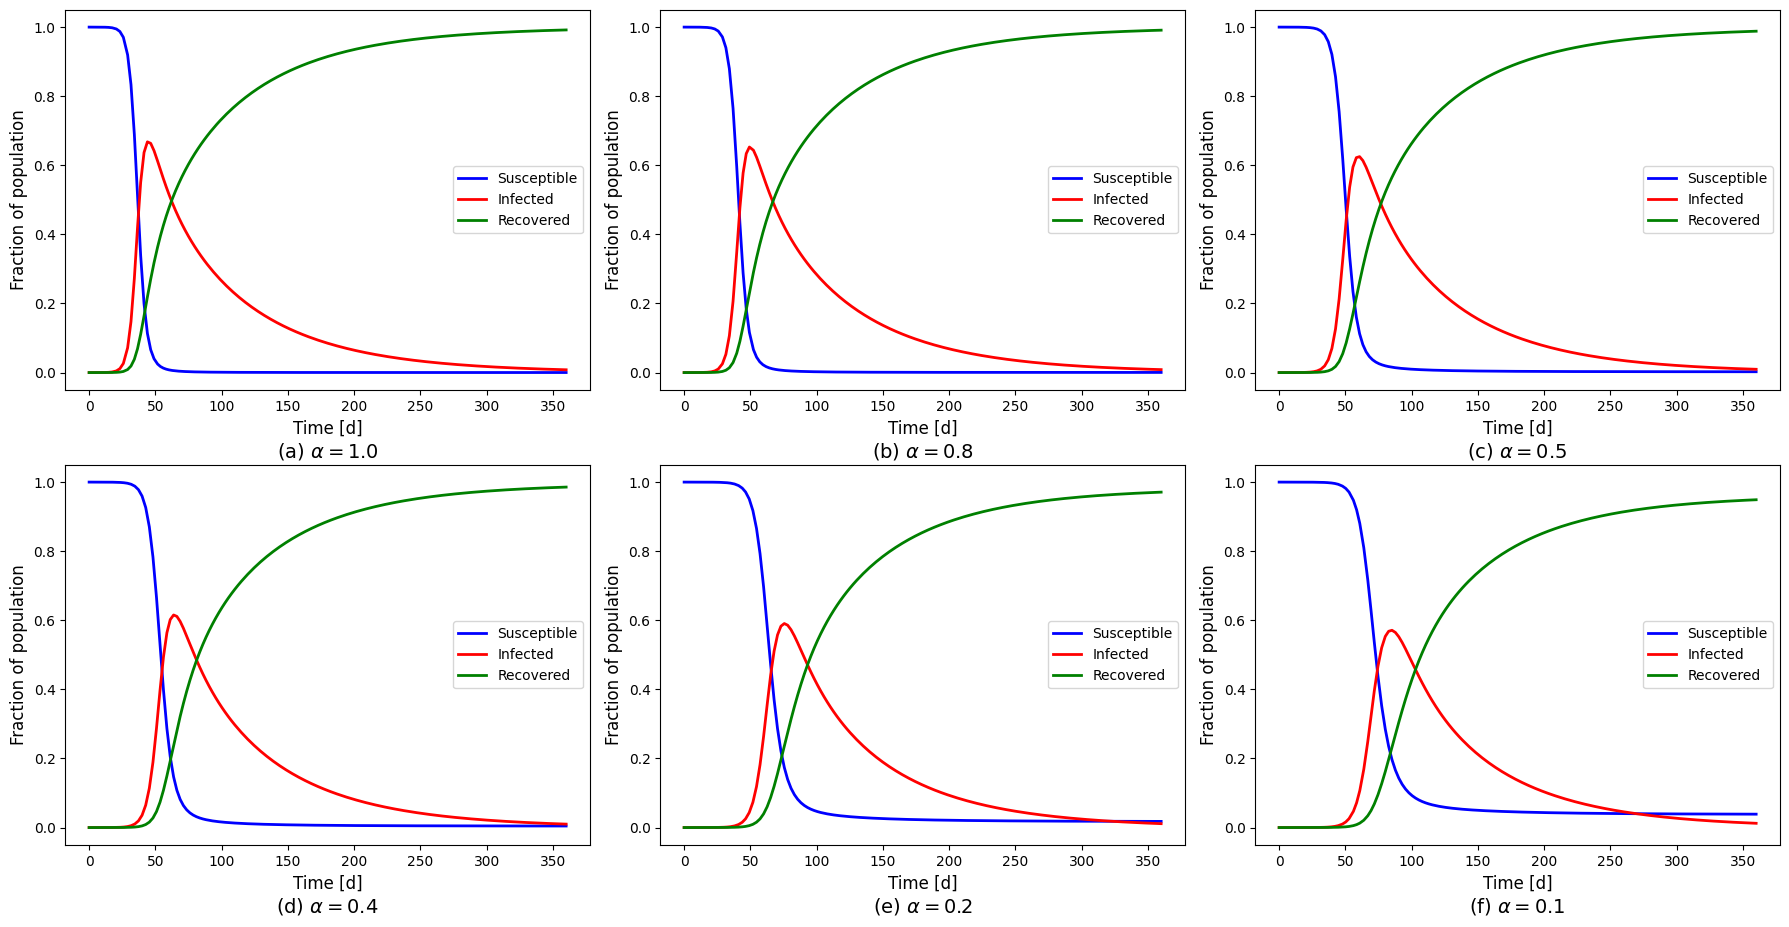

In [8]:
# Seed 0.1% infection in the highest populated country; rest fully susceptible
S0 = population
S0[np.argmax(population)] = 0.999 * np.max(population)

I0 = np.zeros_like(population)
I0[np.argmax(population)] = 0.001 * np.max(population)

print("Location :", valid_countries[np.argmax(population)], "; Population :", np.max(population))

social_connectivity_comp(population, init_state, C,
                          t_end=360, infection_rate=infection_rate, recovery_rate=recovery_rate)

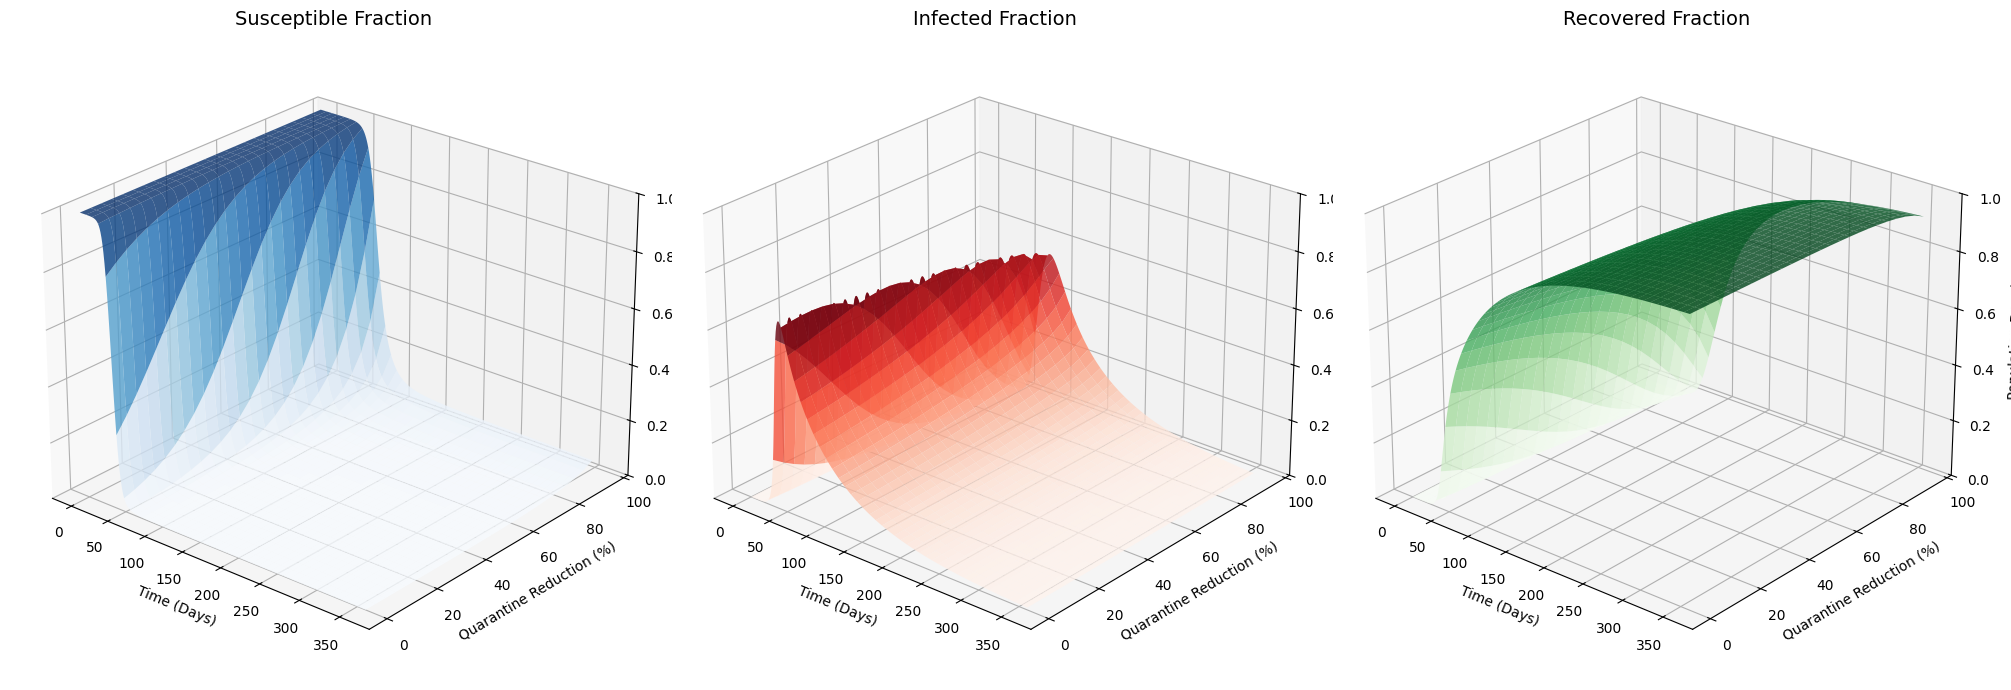

In [9]:
quarantine_plotter_3d(population, init_state, C,
                        infection_rate=infection_rate, recovery_rate=recovery_rate, t_end=360)

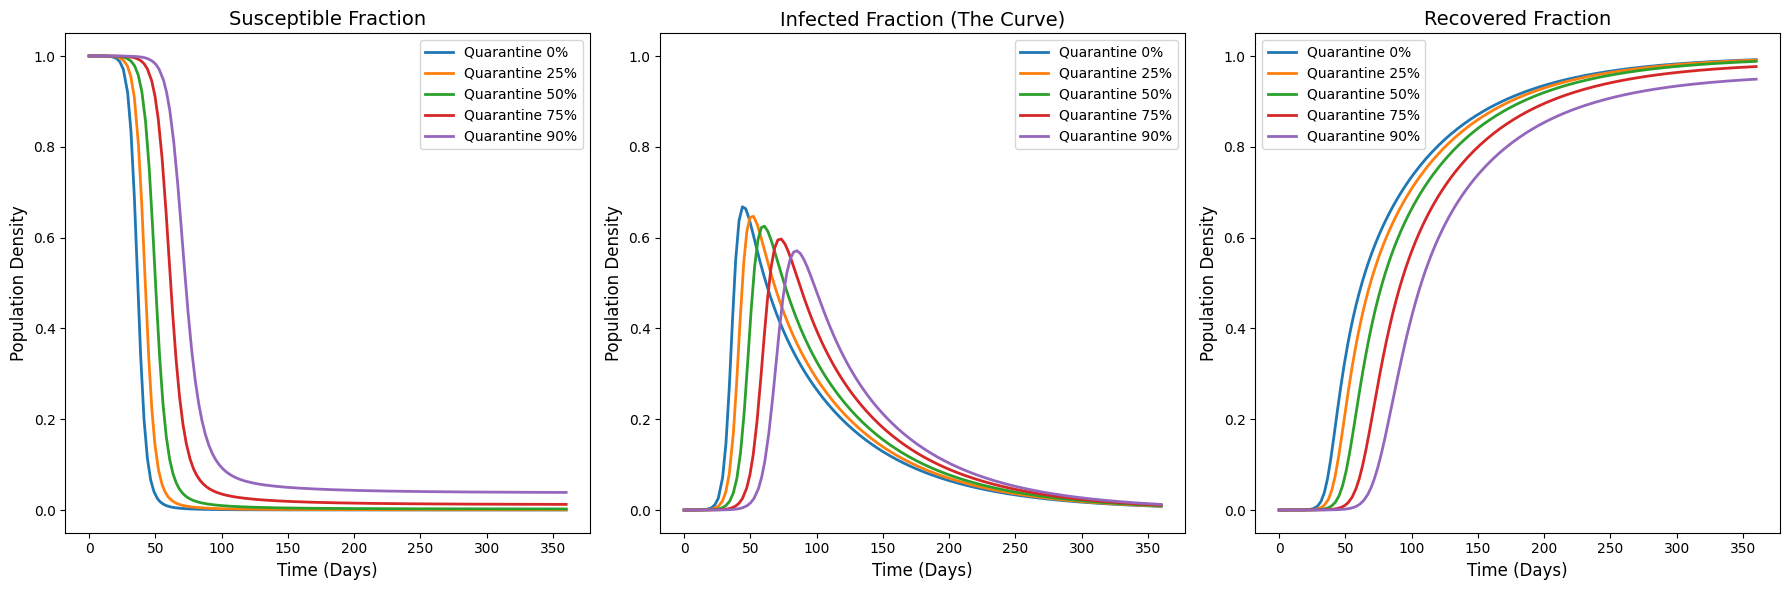

In [10]:
quarantine_plotter_2d(population, init_state, C,
                        infection_rate=infection_rate, recovery_rate=recovery_rate, t_end=360)

Running 400 simulations. Please wait...


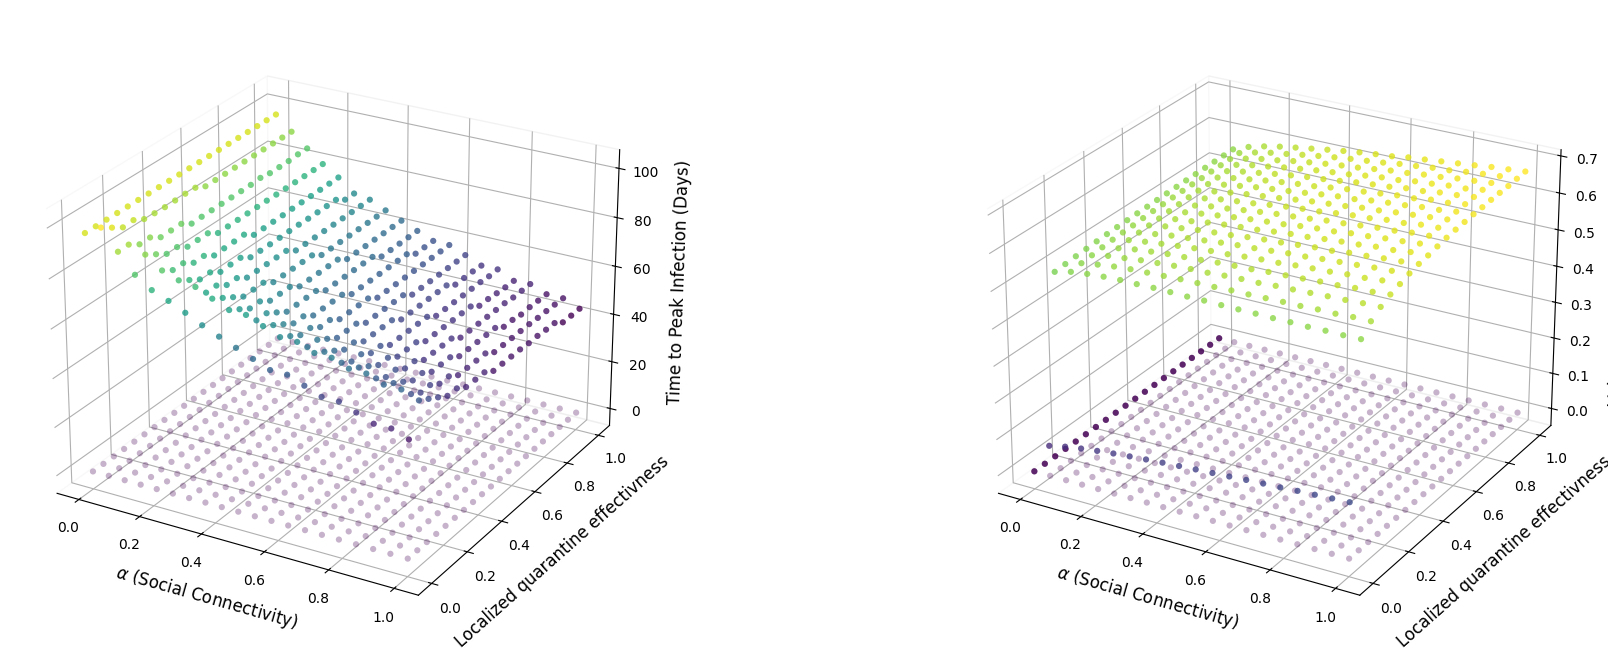

In [11]:
local_vs_global_quarantine(population, init_state, C, infection_rate, recovery_rate, 
                               t_end=360, 
                               quarantine_range=np.linspace(0, 1, 20),
                               top_nodes_under_quarantine=5,
                               social_connectivity_range=np.linspace(0, 1, 20))